# Genre from Spotify features with a neural network

This notebook trains a neural network to predict a track's genre from the Spotify tracks dataset (114k tracks), following the workflow in Juan Francisco Leonhardt's [Music Genre Classification: a Machine Learning exercise](https://medium.com/@juanfraleonhardt/music-genre-classification-a-machine-learning-exercise-9c83108fd2bb).

The article's pipeline: clean the data, drop genres that name a country rather than a sound, merge the remaining ~114 genres into 56 groups that actually sound alike, then train several models. Its results, measured as top-3 accuracy (the right genre is among the model's three best guesses):

| Model | Top-3 accuracy |
|---|---|
| XGBoost | 73.7% |
| KNN (k=10) | 70.4% |
| Neural network (256-128-64-32) | 69.5% |
| Voting ensemble | 65% |

The tree model won and the neural network came third. This notebook keeps the article's data prep but rebuilds the network properly, with the goal of closing that gap.

## Why this model

The model choice deserves more than one line, because the obvious answer is wrong twice.

### The leaderboard models don't apply here

If you search for "best model for music genre classification" you land on CNNs and CNN-Transformer hybrids that read mel-spectrograms, basically images of the audio. Published results on the GTZAN benchmark reach 98-99% accuracy: an [enhanced CNN](https://ieeexplore.ieee.org/document/11188194/), [parallel CNNs](https://www.nature.com/articles/s41598-025-90619-7), and [CNN-Transformer models with attention-based feature fusion](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0344606) (98.7% on GTZAN). The hybrid design wins because the CNN picks up local time-frequency patterns and the transformer ties them together over the length of the clip.

None of that transfers to this dataset, for a boring reason: there is no audio in it. Each track is a row of numbers Spotify already computed (danceability, energy, valence, tempo...) plus a few categorical fields. A convolution needs neighbouring inputs to be related, the way neighbouring pixels are. Our ~30 columns are an arbitrary, unordered list; column 3 is no more "next to" column 4 than to column 19. With no spectrogram to look at, spectrogram models are out, and so is their accuracy ceiling. We work with roughly 20 numbers per song instead of 1.3 million samples of waveform.

### On tables, trees beat networks. Usually.

The strongest model for medium-sized tabular data is, by a wide margin of evidence, gradient-boosted trees. Grinsztajn, Oyallon and Varoquaux ([Why do tree-based models still outperform deep learning on tabular data?](https://arxiv.org/abs/2207.08815), NeurIPS 2022) benchmarked this across 45 datasets and trees won consistently. The article found the same thing the hard way: XGBoost beat its neural network by four points.

The literature also says why the article's network lost. Bare Dense stacks are too smooth for tabular targets (genre boundaries are sharp, irregular functions of the features) and they overfit uninformative columns. Both failure modes are treatable with regularization, which the article's network had none of: no normalization, no dropout, a fixed learning rate of 1e-4, and a fixed epoch count.

### So which network?

Three candidates worth taking seriously:

1. **Tabular transformers (FT-Transformer, TabNet).** These add attention over features. Gorishniy et al. ([Revisiting Deep Learning Models for Tabular Data](https://arxiv.org/abs/2106.11959), NeurIPS 2021) show they edge out a plain MLP by a point or two at best, and only after careful tuning. With 11 numeric features there is very little for attention to attend over; the extra machinery buys almost nothing at this width.
2. **The article's network, rerun harder.** Bigger layers and more epochs without regularization would just overfit faster.
3. **A well-regularized MLP.** Kadra et al. ([Well-tuned Simple Nets Excel on Tabular Datasets](https://arxiv.org/abs/2106.11189), NeurIPS 2021) showed that a plain MLP with a modern regularization cocktail matches or beats both the specialized architectures and tree ensembles across a large benchmark. The architecture isn't the point; the training discipline is.

Option 3 is the model in this notebook. Concretely, five changes over the article's network:

- **Batch normalization** after every hidden layer, so layer inputs stay in a range where gradients are healthy and higher learning rates are safe.
- **Dropout** (0.2-0.3), the main overfitting control; with ~90k training rows and ~250k parameters we need it.
- **Label smoothing** (0.1). Genres genuinely overlap, and many tracks are near-coin-flips between two groups. Smoothing stops the model from burning capacity pushing probabilities to 100% on labels that are partly arbitrary.
- **Early stopping and learning-rate reduction** on validation top-3 accuracy, instead of a fixed epoch budget. The model trains as long as it helps and not a step more.
- **A wider funnel** (512-256-128). Width is cheap on a GPU, and with dropout in place the extra capacity goes to signal, not memorization.

One honest caveat before we start: the ceiling is set by the data, not the model. The same audio profile legitimately belongs to several genres (a track can be disco and funk), so exact-match accuracy stalls around 45-50% no matter what trains on these features. Top-3 accuracy is the fairer metric, which is why the article reports it and we do too. If you actually need more than ~75%, the move isn't a fancier tabular model, it's getting the audio and fine-tuning a pretrained spectrogram model like the ones above.

## 1. Setup

Everything used here ships with Colab; nothing to install.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from scipy.cluster.hierarchy import linkage, fcluster

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'none (training will be slow)')

TensorFlow 2.20.0
GPU: none (training will be slow)


## 2. Load the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/google_colab/spotify_tracks_dataset_114k.csv'
df = pd.read_csv(path, index_col=0)
print(df.shape)
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## 3. Cleaning

Three steps, all following the article:

1. Drop the handful of rows with missing names.
2. Drop genres named after a country or language. "British" or "turkish" describe where music comes from, not what it sounds like, and the audio features can't tell a British rock song from any other rock song.
3. Deduplicate. The dataset stores the same `track_id` once per genre with identical features. Left in, those copies poison the experiment twice: the same row lands in both train and test (leakage, inflates scores), and the model is taught that one input has several correct answers (noise, deflates learning). We shuffle before dropping so the genre that keeps each track is random rather than whichever comes first alphabetically.

In [3]:
df = df.dropna(subset=['artists', 'album_name', 'track_name'])

NON_AUDIO_GENRES = ['british', 'french', 'german', 'indian', 'iranian', 'malay',
                    'swedish', 'turkish', 'brazil', 'spanish', 'world-music']
df = df[~df['track_genre'].isin(NON_AUDIO_GENRES)]

df = df.sample(frac=1, random_state=SEED).drop_duplicates(subset='track_id')

print(f"{len(df):,} tracks, {df['track_genre'].nunique()} genres")

81,513 tracks, 103 genres


## 4. Merge genres that sound alike

The article's most consequential preprocessing step. The raw labels include sets like house / deep-house / progressive-house / chicago-house, which are close to indistinguishable in these features. Asking the model to split them just converts label granularity into error.

The fix, as in the article: describe each genre by its average audio profile, cluster the profiles hierarchically (Ward linkage, which merges the two closest-sounding genres at every step), and cut the tree at 56 groups. The model then predicts the group.

In [4]:
AUDIO_FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence',
                  'tempo']

# Average audio profile per genre, standardized so every feature counts equally.
centroids = df.groupby('track_genre')[AUDIO_FEATURES].mean()
centroids_scaled = StandardScaler().fit_transform(centroids)

N_GROUPS = 56
merged = fcluster(linkage(centroids_scaled, method='ward'),
                  t=N_GROUPS, criterion='maxclust')

# Name each group after its member genres (first three, plus a count).
group_members = {}
for genre, g in zip(centroids.index, merged):
    group_members.setdefault(g, []).append(genre)
group_name = {g: '/'.join(sorted(m)[:3]) + (f'+{len(m) - 3}' if len(m) > 3 else '')
              for g, m in group_members.items()}

genre_to_group = {genre: group_name[g] for genre, g in zip(centroids.index, merged)}
df['genre_group'] = df['track_genre'].map(genre_to_group)

# Eyeball the biggest merges; they should make musical sense.
for g, m in sorted(group_members.items(), key=lambda kv: -len(kv[1]))[:8]:
    print(f"{len(m):2d} genres: {', '.join(m)}")

 5 genres: acoustic, cantopop, mandopop, singer-songwriter, songwriter
 5 genres: alt-rock, garage, goth, hard-rock, j-rock
 4 genres: alternative, edm, groove, house
 4 genres: blues, folk, pop-film, soul
 4 genres: electro, indie, indie-pop, pop
 4 genres: hip-hop, latino, reggae, reggaeton
 4 genres: j-idol, power-pop, punk, punk-rock
 3 genres: club, deep-house, electronic


## 5. Features and split

Inputs are the nine audio features plus duration and popularity (the article used both; popularity isn't audio, but it carries genre signal, e.g. niche genres rarely chart). Key, mode and time signature are one-hot encoded: their integer codes are categories, and feeding key 11 as "more than" key 2 would be nonsense. With at most 12 categories each, one-hot is the right tool; embeddings only pay off at much higher cardinality.

70/15/15 train/validation/test, stratified so every group is present in all three sets. The scaler is fitted on the training set only, since fitting it on everything would leak test statistics into training.

In [5]:
NUMERIC = AUDIO_FEATURES + ['duration_ms', 'popularity']
CATEGORICAL = ['key', 'mode', 'time_signature']

X = pd.get_dummies(df[NUMERIC + CATEGORICAL + ['explicit']],
                   columns=CATEGORICAL).astype('float32')

labels = LabelEncoder().fit(df['genre_group'])
y = labels.transform(df['genre_group'])
n_classes = len(labels.classes_)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X.values, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f'features: {X.shape[1]}, classes: {n_classes}')
print(f'train {len(X_train):,} / val {len(X_val):,} / test {len(X_test):,}')

features: 31, classes: 56
train 57,059 / val 12,227 / test 12,227


## 6. The model

The regularized MLP argued for above: three hidden blocks of Dense, then batch norm, then ReLU, then dropout, funneling 512 to 256 to 128, with a softmax over the genre groups. Batch norm goes between the linear layer and the activation, the placement from the original paper.

About 250k parameters. Tiny by deep learning standards, which is appropriate: the input is 30-ish columns, and on tabular data extra depth past 3-4 layers consistently fails to pay rent.

In [6]:
def build_model(n_features, n_classes):
    return keras.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),

        layers.Dense(n_classes, activation='softmax'),
    ])

model = build_model(X_train.shape[1], n_classes)
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[keras.metrics.CategoricalAccuracy(name='acc'),
             keras.metrics.TopKCategoricalAccuracy(k=3, name='top3')],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 56)             │         7,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,416 (747.72 KB)

 Trainable params: 189,624 (740.72 KB)

 Non-trainable params: 1,792 (7.00 KB)

## 7. Training

The learning rate starts at 1e-3 (ten times the article's; batch norm makes that safe) and halves whenever validation top-3 accuracy stalls for 4 epochs. Training stops after 12 stalled epochs and rolls back to the best weights. Class weights compensate for the unbalanced group sizes the dedup left behind.

The epoch budget of 200 is a ceiling, not a target; early stopping usually ends training well before it.

In [7]:
y_train_oh = keras.utils.to_categorical(y_train, n_classes)
y_val_oh = keras.utils.to_categorical(y_val, n_classes)

weights = compute_class_weight('balanced', classes=np.arange(n_classes), y=y_train)
class_weight = dict(enumerate(weights))

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_top3', mode='max', patience=12,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_top3', mode='max', factor=0.5,
                                      patience=4, min_lr=1e-5),
]

history = model.fit(X_train, y_train_oh,
                    validation_data=(X_val, y_val_oh),
                    epochs=200, batch_size=512,
                    class_weight=class_weight,
                    callbacks=callbacks, verbose=2)

Epoch 1/200
112/112 - 8s - 67ms/step - acc: 0.1394 - loss: 3.4467 - top3: 0.2859 - val_acc: 0.2494 - val_loss: 3.1448 - val_top3: 0.4664 - learning_rate: 0.0010
Epoch 2/200
112/112 - 3s - 30ms/step - acc: 0.2366 - loss: 2.9535 - top3: 0.4488 - val_acc: 0.2997 - val_loss: 2.8663 - val_top3: 0.5400 - learning_rate: 0.0010
Epoch 3/200
112/112 - 5s - 47ms/step - acc: 0.2667 - loss: 2.8268 - top3: 0.4953 - val_acc: 0.3165 - val_loss: 2.7724 - val_top3: 0.5593 - learning_rate: 0.0010
Epoch 4/200
112/112 - 3s - 29ms/step - acc: 0.2842 - loss: 2.7612 - top3: 0.5170 - val_acc: 0.3281 - val_loss: 2.7312 - val_top3: 0.5715 - learning_rate: 0.0010
Epoch 5/200
112/112 - 3s - 30ms/step - acc: 0.3005 - loss: 2.7098 - top3: 0.5303 - val_acc: 0.3357 - val_loss: 2.6975 - val_top3: 0.5829 - learning_rate: 0.0010
Epoch 6/200
112/112 - 3s - 29ms/step - acc: 0.3084 - loss: 2.6678 - top3: 0.5449 - val_acc: 0.3446 - val_loss: 2.6663 - val_top3: 0.5915 - learning_rate: 0.0010
Epoch 7/200
112/112 - 5s - 46ms/st

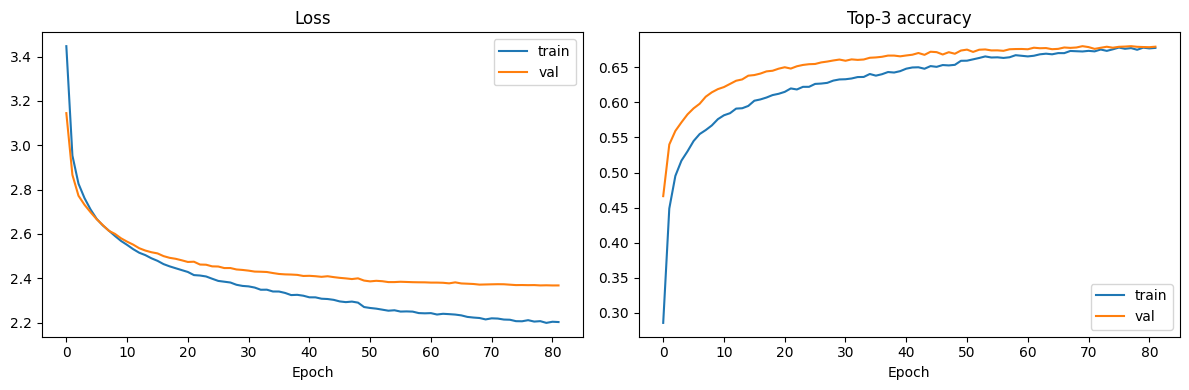

In [8]:
hist = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['loss'], label='train')
axes[0].plot(hist['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist['top3'], label='train')
axes[1].plot(hist['val_top3'], label='val')
axes[1].set_title('Top-3 accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Results

Test-set numbers, plus the article's for reference. Note the comparison is directional, not exact: our dedup and random-keep policy differ in detail from the article's cleanup, so the test sets aren't identical.

In [9]:
y_test_oh = keras.utils.to_categorical(y_test, n_classes)
loss, acc, top3 = model.evaluate(X_test, y_test_oh, verbose=0)

print(f'Test accuracy:        {acc:.2%}')
print(f'Test top-3 accuracy:  {top3:.2%}')
print()
print('Article reference: NN 69.5% top-3, XGBoost 73.7% top-3')

Test accuracy:        43.16%
Test top-3 accuracy:  67.69%

Article reference: NN 69.5% top-3, XGBoost 73.7% top-3


In [10]:
# Where the model is confused: the most frequent wrong (true -> predicted) pairs.
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, pred)
np.fill_diagonal(cm, 0)

flat = np.argsort(cm, axis=None)[-10:]
for i, j in zip(*np.unravel_index(flat[::-1], cm.shape)):
    print(f'{cm[i, j]:4d}  {labels.classes_[i]}  ->  {labels.classes_[j]}')

  77  alt-rock/garage/goth+2  ->  grunge/metal
  60  dance/k-pop/latin  ->  hip-hop/latino/reggae+1
  49  ambient/new-age  ->  piano
  45  electro/indie/indie-pop+1  ->  dance/k-pop/latin
  42  j-idol/power-pop/punk+1  ->  party/ska
  42  acoustic/cantopop/mandopop+2  ->  gospel
  41  acoustic/cantopop/mandopop+2  ->  bluegrass/rock-n-roll
  37  blues/folk/pop-film+1  ->  country/j-pop/rock
  35  heavy-metal/metalcore  ->  death-metal
  35  alt-rock/garage/goth+2  ->  heavy-metal/metalcore


## 9. The tree baseline

The literature says XGBoost should be hard to beat on this data, and skipping the comparison would just leave that question open. Same features, same split.

In [11]:
from xgboost import XGBClassifier

xgb = XGBClassifier(objective='multi:softprob', n_estimators=400, max_depth=8,
                    learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                    tree_method='hist', random_state=SEED)
xgb.fit(X_train, y_train)

xgb_probs = xgb.predict_proba(X_test)
top3_sets = np.argsort(xgb_probs, axis=1)[:, -3:]
xgb_acc = (xgb_probs.argmax(axis=1) == y_test).mean()
xgb_top3 = np.mean([t in row for t, row in zip(y_test, top3_sets)])

print(f'XGBoost test accuracy:        {xgb_acc:.2%}')
print(f'XGBoost test top-3 accuracy:  {xgb_top3:.2%}')

XGBoost test accuracy:        50.98%
XGBoost test top-3 accuracy:  73.57%


## Takeaways

Run the notebook to fill in the numbers, then judge the network against three bars:

- The article's network (69.5% top-3). The regularization changes should clear this comfortably; if not, something in the pipeline is off.
- The article's XGBoost (73.7% top-3) and our own XGBoost cell above. Matching the trees on tabular data is a good outcome for an MLP; beating them clearly would be unusual and worth double-checking for leakage.
- The data ceiling. The confused-pairs list shows where the remaining error lives; most of it is groups that genuinely overlap in audio space. Past that point, better models don't help. More informative inputs would: lyrics, artist metadata, or the actual audio feeding a pretrained spectrogram model.